In [1]:
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sqlalchemy import create_engine

username = 'root'
password = '7999590423'
host = 'localhost'
port = '3306'
database = 'superstore_db'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

In [3]:
with engine.connect() as conn:
    print('Connected to MYSQL successfully')

Connected to MYSQL successfully


In [4]:
## Data Reading :

query = """
SELECT 
   o.order_id,
    o.customer_id,
    o.product_id,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.country,
    o.state,
    o.city,
    o.region,
    o.postal_code,
    o.sales,
    o.quantity,
    o.discount,
    o.profit,
    o.shipping_cost,

    p.product_name,
    p.category,
    p.sub_category,

    c.customer_name,
    c.segment,

    COALESCE(r.Returned,'No') AS returned,
    r.market

FROM orders o
JOIN products p
ON o.product_id = p.product_id

JOIN customers c
ON o.customer_id = c.customer_id

LEFT JOIN returns r
ON o.order_id = r.`Order ID`;
"""
df = pd.read_sql(query, engine)
df

,order_id,customer_id,product_id,order_date,ship_date,ship_mode,country,state,city,region,...,discount,profit,shipping_cost,product_name,category,sub_category,customer_name,segment,returned,market
0,CG-2014-7660,PH-8790,FUR-ADV-10000002,2014-05-08,2014-05-13,Standard Class,Democratic Republic of the Congo,Kinshasa,Kinshasa,Africa,...,0.0,40.26,6.11,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Patricia Hirasaki,Home Office,No,None
1,IZ-2014-4660,TB-11190,FUR-ADV-10000002,2014-09-08,2014-09-15,Standard Class,Iraq,Baghdad,Baghdad,EMEA,...,0.0,20.13,4.03,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Thomas Brumley,Home Office,No,None
2,RW-2012-8200,SG-10890,FUR-ADV-10000108,2012-02-20,2012-02-24,Standard Class,Rwanda,Kigali,Kigali,Africa,...,0.0,1.92,10.80,"Advantus Clock, Erganomic",Furniture,Furnishings,Susan Gilcrest,Corporate,No,None
3,LI-2011-9980,PM-9135,FUR-ADV-10000108,2011-04-13,2011-04-15,Second Class,Liberia,Montserrado,Monrovia,Africa,...,0.0,0.96,9.27,"Advantus Clock, Erganomic",Furniture,Furnishings,Peter McVee,Home Office,No,None
4,MO-2012-8110,AR-540,FUR-ADV-10000108,2012-05-10,2012-05-17,Standard Class,Morocco,Grand Casablanca,Casablanca,Africa,...,0.0,0.48,2.83,"Advantus Clock, Erganomic",Furniture,Furnishings,Andy Reiter,Consumer,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51290,MZ-2013-3540,EH-4005,TEC-STA-10004542,2013-04-19,2013-04-23,Standard Class,Mozambique,Sofala,Beira,Africa,...,0.0,12.00,4.68,"StarTech Calculator, Durable",Technology,Machines,Erica Hernandez,Home Office,No,None
51291,TU-2014-8160,SC-10260,TEC-STA-10004542,2014-07-07,2014-07-13,Standard Class,Turkey,Istanbul,Istanbul,EMEA,...,0.6,-18.05,1.62,"StarTech Calculator, Durable",Technology,Machines,Scott Cohen,Corporate,No,None
51292,TU-2011-790,CC-2145,TEC-STA-10004834,2011-11-03,2011-11-08,Standard Class,Turkey,Adana,Adana,EMEA,...,0.6,-107.83,13.61,"StarTech Receipt Printer, Red",Technology,Machines,Charles Crestani,Consumer,No,None
51293,NI-2013-7410,CD-1920,TEC-STA-10004834,2013-08-28,2013-09-03,Standard Class,Nigeria,Kano,Kano,Africa,...,0.7,-37.73,5.77,"StarTech Receipt Printer, Red",Technology,Machines,Carlos Daly,Consumer,No,None


In [5]:
 # Changing the data type of shipping_date and order_date column 

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])


In [6]:
df.dtypes

order_id                 object
customer_id              object
product_id               object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
country                  object
state                    object
city                     object
region                   object
postal_code              object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
shipping_cost           float64
product_name             object
category                 object
sub_category             object
customer_name            object
segment                  object
returned                 object
market                   object
dtype: object

In [7]:
# # dropping the market column

df.drop(columns = ['market'], inplace = True)

# Customer Segment Analysis:

### Customer distribution by segment:

In [8]:
query = """
SELECT 
    segment,
    COUNT(DISTINCT customer_id) AS customer_count
FROM customers
    GROUP BY segment;
"""

customer_by_segment = pd.read_sql(query, engine)

customer_by_segment

,segment,customer_count
0,Consumer,818
1,Corporate,476
2,Home Office,296


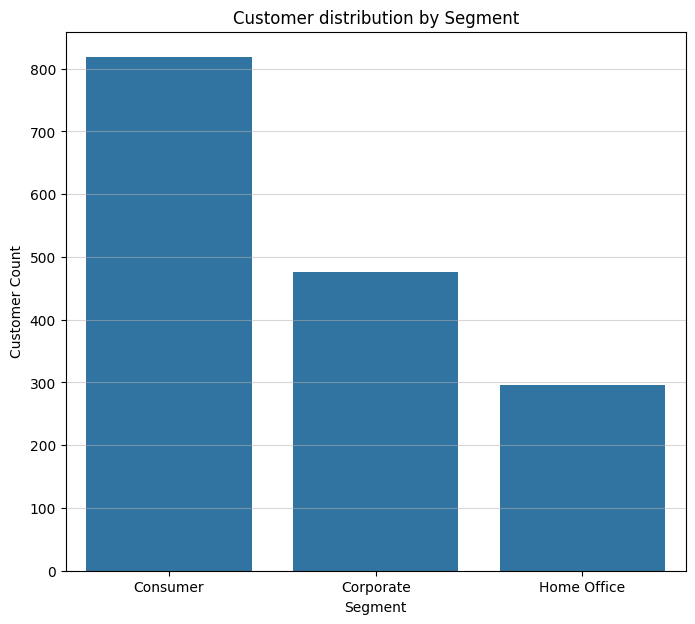

In [17]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'segment',
            y = 'customer_count',
            data = customer_by_segment
           )
plt.title('Customer distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Customer Count')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()




### Order Volume by Customer segment:

In [19]:
query = """
SELECT 
    c.segment,
    COUNT(o.order_item_id) AS order_line_count
FROM orders o 
JOIN customers c 
ON o.customer_id = c.customer_id 
GROUP BY c.Segment
ORDER BY order_line_count DESC;
"""
order_volume_by_customer_segment = pd.read_sql(query, engine)

order_volume_by_customer_segment

,segment,order_line_count
0,Consumer,26518
1,Corporate,15429
2,Home Office,9343


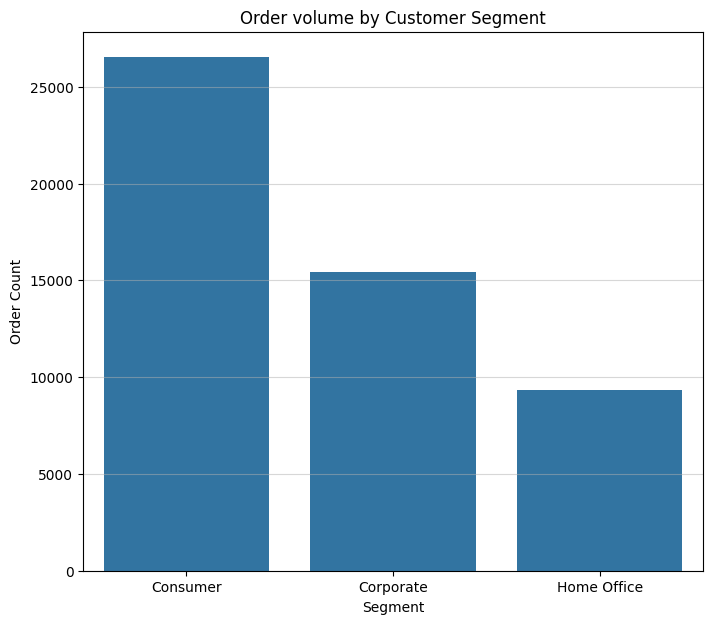

In [20]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'segment',
            y = 'order_line_count',
            data = order_volume_by_customer_segment
           )
plt.title('Order volume by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Order Count')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()




### Sales by Customer Segment:

In [24]:
query = """
SELECT 
    c.segment,
    ROUND(SUM(o.sales), 2) AS total_sales
    FROM orders o   
JOIN customers c
ON o.customer_id = c.customer_id
GROUP BY c.Segment
ORDER BY total_sales DESC;
"""
sales_by_customer_segment = pd.read_sql(query, engine)

sales_by_customer_segment

,segment,total_sales
0,Consumer,6507952.31
1,Corporate,3824698.96
2,Home Office,2309855.98


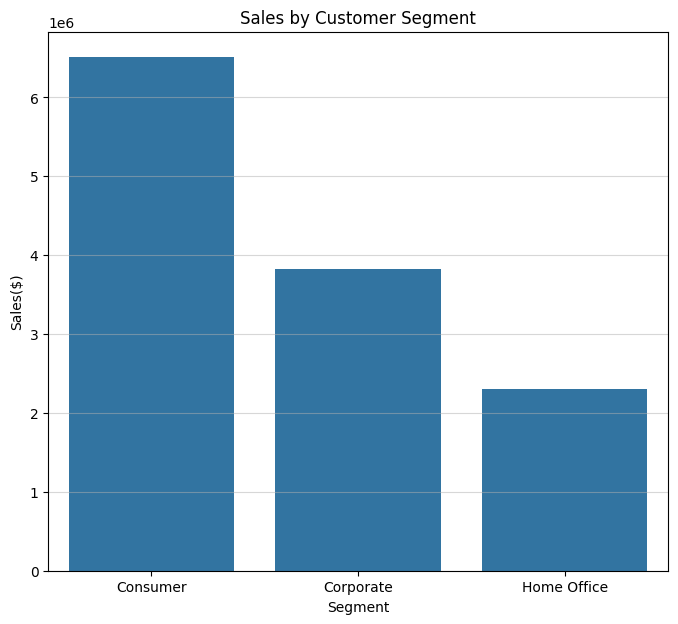

In [25]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'segment',
            y = 'total_sales',
            data = sales_by_customer_segment
           )
plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Sales($)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()




##  Profit by customer segment analysis:

In [27]:
query = """
SELECT 
    c.segment,
    ROUND(SUM(o.sales), 2) AS total_sales,
    ROUND(SUM(o.profit), 2) AS total_profit,
    ROUND(SUM(o.profit)/SUM(o.sales) * 100, 2) AS profit_perct
    FROM orders o   
JOIN customers c
ON o.customer_id = c.customer_id
GROUP BY c.Segment
ORDER BY total_profit DESC;
"""
Profit_margin_by_customer_segment = pd.read_sql(query, engine)

Profit_margin_by_customer_segment

,segment,total_sales,total_profit,profit_perct
0,Consumer,6507952.31,749239.18,11.51
1,Corporate,3824698.96,441208.09,11.54
2,Home Office,2309855.98,277009.28,11.99


### Profit by customer segment

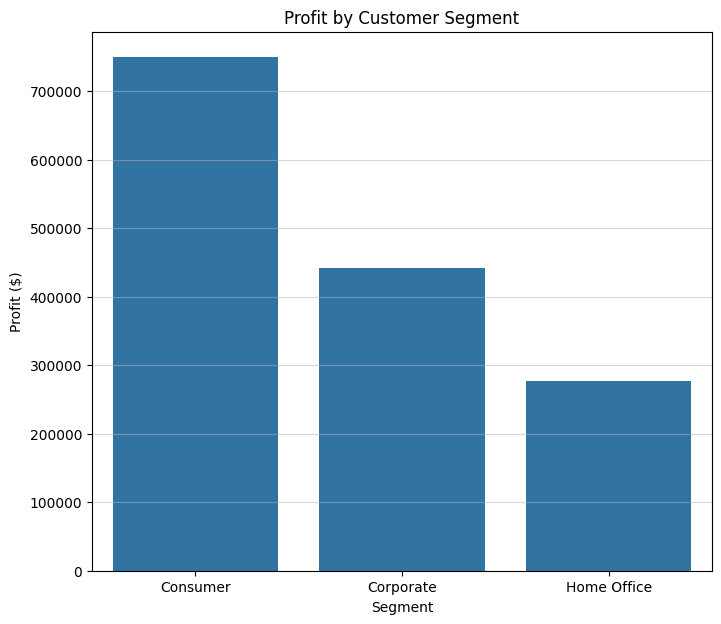

In [32]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'segment',
            y = 'total_profit',
            data = Profit_margin_by_customer_segment
           )
plt.title('Profit by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Profit ($)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()




### Profit margin by customer segment

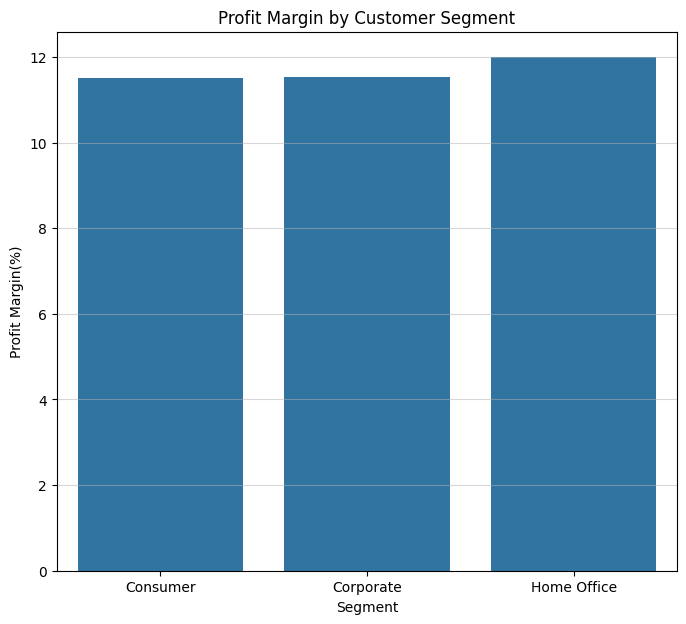

In [29]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'segment',
            y = 'profit_perct',
            data = Profit_margin_by_customer_segment
           )
plt.title('Profit Margin by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Profit Margin(%)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()




### Average Order Value (AOV) by Customer Segment:

In [35]:
query = """
SELECT 
    c.segment,
    ROUND(SUM(o.sales) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
FROM orders o 
JOIN customers c 
ON o.customer_id = c.customer_id
GROUP BY c.segment;
"""
aov_customer_segment = pd.read_sql(query, engine)

aov_customer_segment


,segment,avg_order_value
0,Consumer,496.64
1,Corporate,498.46
2,Home Office,492.82


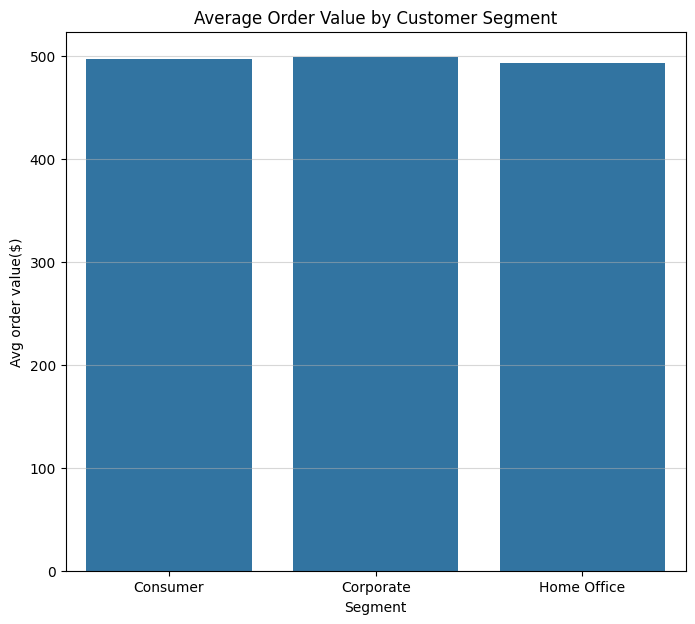

In [36]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'segment',
            y = 'avg_order_value',
            data = aov_customer_segment
           )
plt.title('Average Order Value by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Avg order value($)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()




## Top 10 most valuable customer :

In [ ]:
query = """ 
SELECT 
    c.customer_id,
    c.customer_name,
    COUNT(DISTINCT o.order_id) AS order_frequency,
    ROUND(SUM(o.sales),2) AS total_sales,
    ROUND(SUM(o.profit),2) AS total_profit
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
GROUP BY 
    c.customer_id,
    c.customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""

most_valuable_customers = pd.read_sql(query, engine)

most_valuable_customers

,customer_id,customer_name,order_frequency,total_sales,total_profit
0,TA-21385,Tom Ashbrook,25,35668.14,6275.02
1,GT-14710,Greg Tran,30,34471.90,5164.83
2,TC-20980,Tamara Chand,28,34218.28,8787.48
3,SM-20320,Sean Miller,21,31125.34,-1083.68
4,BW-11110,Bart Watters,35,30613.63,3337.45
5,HL-15040,Hunter Lopez,20,29664.26,7657.50
6,SE-20110,Sanjit Engle,36,29532.63,5863.62
7,PS-19045,Penelope Sewall,26,29252.33,4426.21
8,RB-19360,Raymond Buch,25,29197.65,8523.95
9,ZC-21910,Zuschuss Carroll,37,28472.81,452.51


### Top 10 customers Order Frequency :

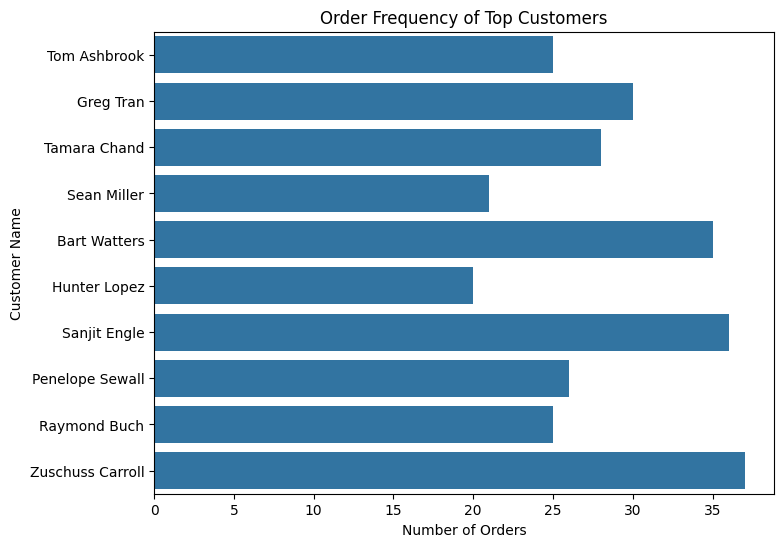

In [59]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='order_frequency',
    y='customer_name',
    data=most_valuable_customers
)

plt.title('Order Frequency of Top Customers')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Name')

plt.show()

### Top 10 customer by profit

In [39]:
query = """
SELECT 
    c.customer_name,
    c.segment,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(sales), 2) AS total_sales
FROM orders o 
JOIN customers c 
ON c.customer_id = o.customer_id
GROUP BY c.customer_name, c.Segment
ORDER BY total_profit DESC
LIMIT 10;
"""
customer_by_profit = pd.read_sql(query, engine)

customer_by_profit

,customer_name,segment,total_profit,total_sales
0,Tamara Chand,Corporate,8672.90,37457.34
1,Raymond Buch,Consumer,8453.05,29602.16
2,Sanjit Chand,Consumer,8205.37,26521.13
3,Hunter Lopez,Consumer,7816.57,30243.60
4,Bill Eplett,Home Office,7410.01,28479.17
5,Harry Marie,Corporate,6958.26,28476.95
6,Susan Pistek,Consumer,6484.41,29020.60
7,Mike Gockenbach,Consumer,6458.64,23377.06
8,Adrian Barton,Consumer,6417.27,25123.19
9,Tom Ashbrook,Home Office,6312.01,40488.09


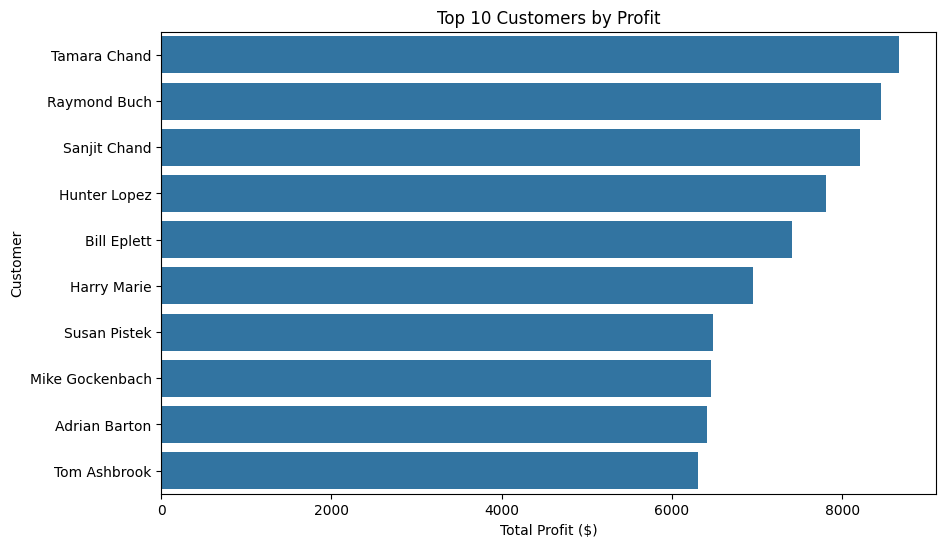

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='total_profit',
    y='customer_name',
    data=customer_by_profit,
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Total Profit ($)")
plt.ylabel("Customer")

plt.show()



### Top 10 customers by sales

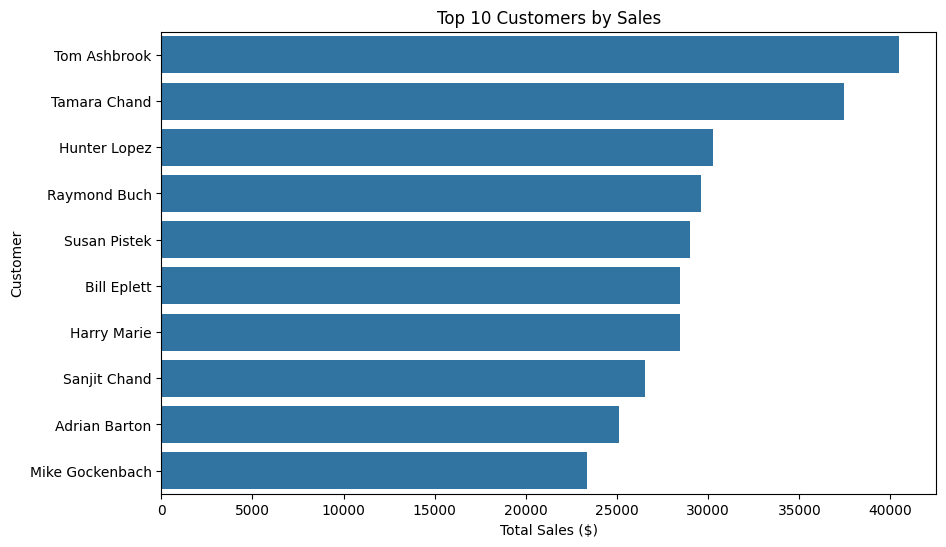

In [60]:
customer_by_profit = customer_by_profit.sort_values(
    by='total_sales',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='total_sales',
    y='customer_name',
    data=customer_by_profit,
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")

plt.show()



### Customer with high order volume but with negative profit:

In [50]:
query = """
SELECT 
    c.customer_name,
    COUNT(DISTINCT o.order_id) AS order_frequency,
    ROUND(SUM(o.profit), 2)    AS total_profit
FROM orders o 
JOIN customers c 
ON o.customer_id = c.customer_id
GROUP BY c.customer_name
HAVING order_frequency >= 10
AND total_profit < 0
ORDER BY total_profit DESC
LIMIT 10;
"""
customer_with_high_order_but_negative_profit = pd.read_sql(query, engine)
customer_with_high_order_but_negative_profit

,customer_name,order_frequency,total_profit
0,Christine Sundaresam,40,-1.15
1,Chad Sievert,26,-4.07
2,Greg Maxwell,26,-11.39
3,Rick Reed,34,-47.97
4,Linda Southworth,32,-67.86
5,Dan Campbell,38,-70.52
6,Tracy Zic,24,-80.11
7,Joy Smith,36,-103.01
8,Michael Grace,34,-117.61
9,Jill Stevenson,24,-161.19


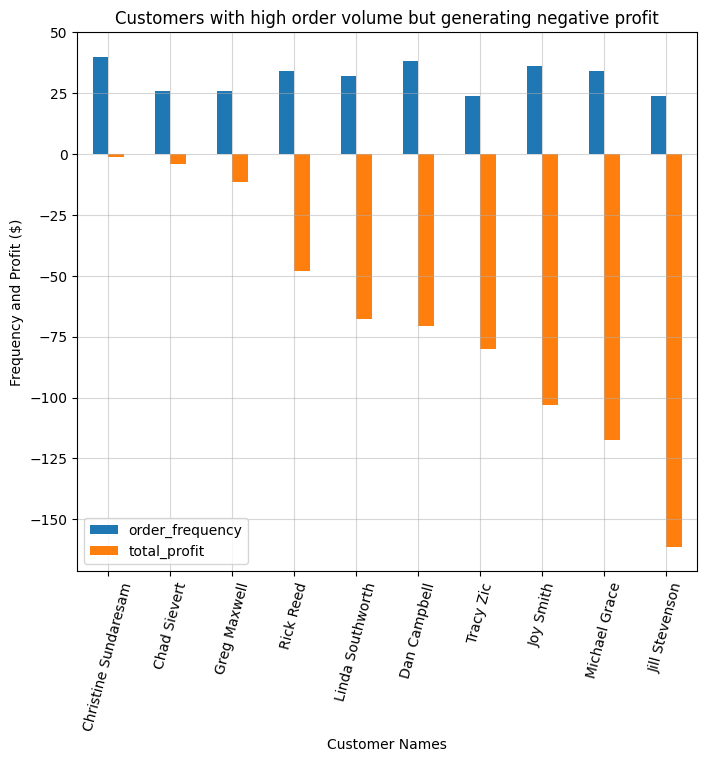

In [51]:
customer_with_high_order_but_negative_profit.plot(x = 'customer_name',
                                y = ['order_frequency','total_profit'],
                                kind = 'bar',
                                figsize = (8,7)
                               )
plt.title('Customers with high order volume but generating negative profit')
plt.xlabel('Customer Names')
plt.ylabel('Frequency and Profit ($)')
plt.xticks(rotation = 75)
plt.grid(alpha = 0.5)

plt.show()

# Summary :

### Key Insights of Customer Segment Analysis

### 1. Which group buys the most?
* **Consumer Group is Number 1:** This is the biggest group. They have the most customers, buy the most items, and bring in the most money.
* **Other Groups:** The **Corporate** group is in second place. The **Home Office** group is the smallest, but they are still important.

### 2. Profit and Spending
* **Spending is the same:** On average, every customer spends about **$500** per order. It doesn't matter which group they belong to; they all spend a similar amount.
* **Good Profits:** All groups make about **11-12%** profit. Even though the **Home Office** group is small, they actually make a slightly better profit percentage than the others.

### 3. Best Customers
* **Star Customers:** People like **Tom Ashbrook** and **Tamara Chand** are the best customers because they bring in high sales and high profits.
* **Most Frequent Buyer:** **Zuschuss Carroll** is the most loyal customer because they place orders more often than anyone else.

### 4. Important Problem: Losing money on active customers
* **High Sales but No Profit:** Some customers (like **Daniel Grace** and **Tracy Zic**) buy many things but the company actually **loses money** on them.
* **Why this happens:** These customers are likely using too many discounts or only buying very cheap items. The company needs to check its discount rules for these specific people.